# Logistic Regression training and protocol comparison

## tl;dr

- **Cross-subject:** mean per-pixel balanced accuracy `0.5100`, 95% complete-subject bootstrap interval `[0.4964, 0.5211]`; selected family `lbp`.
- **Identity-overlapping bidirectional cross-trial:** combined balanced accuracy `0.5000`, interval `[0.4861, 0.5115]`; Trial 1 -> Trial 2 selected `correlation`, while Trial 2 -> Trial 1 selected `time+spectral`.
- Both intervals include chance (`0.5`). The within-subject result does not improve on the primary subject-generalization estimate despite overlapping identities.
- This is not a pure model-effect comparison: the protocols use different evaluation populations and ask different generalization questions. They are reported separately and never averaged.

## Context & Methods

The prediction unit is one full random-imagery `[0.5, 15.5)` block mapped to a row-major 6x6 binary image. The input is `Data_Pattern/patt`, `type="random"`; EOG is not used as a model input. Feature-family screening, grouped inner cross-validation, feature selection, scaling, and per-pixel Logistic Regression tuning are fitted only on each direction's training rows.

### Key Assumptions

- Cross-subject is the primary subject-generalization estimate and keeps train/test identities disjoint.
- Within-subject is **identity-overlapping bidirectional cross-trial transfer**, not a separately fitted model per subject.
- Trial 1 -> Trial 2 and Trial 2 -> Trial 1 are trained independently and combined only after prediction.
- Complete subjects are the bootstrap unit. The combined within-subject interval preserves all six out-of-trial rows for each sampled subject.
- The protocol comparison is descriptive because evaluation populations and generalization targets differ.

## Data

### 1. Parameters and reusable workflow

`REUSE_EXISTING=True` validates and reuses complete immutable run sets. If no expected run exists, the same call performs training and publishes schema-v2 artifacts atomically.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

CONFIG_PATH = PROJECT_ROOT / "confs/experiments/logistic_regression.yaml"
OVERRIDES = []
PROTOCOLS = ("cross-subject", "within-subject")
REUSE_EXISTING = True

CONFIG_PATH, OVERRIDES, PROTOCOLS, REUSE_EXISTING

(PosixPath('/home/slauva/Projects/master-thesis-2024-2026/code/confs/experiments/logistic_regression.yaml'),
 [],
 ('cross-subject', 'within-subject'),
 True)

In [2]:
import json
import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from experiments.logistic_regression import (
    execute_evaluation_protocol,
    load_logistic_regression_config,
    parse_dotted_overrides,
)

config = load_logistic_regression_config(
    config_path=CONFIG_PATH,
    overrides=parse_dotted_overrides(OVERRIDES),
)
workflow_results = {
    protocol: execute_evaluation_protocol(
        protocol,
        config=config,
        reuse_existing=REUSE_EXISTING,
    )
    for protocol in PROTOCOLS
}

{
    protocol: {
        "reused": result.reused,
        "run_dirs": [str(path) for path in result.run_dirs],
    }
    for protocol, result in workflow_results.items()
}

{'cross-subject': {'reused': True,
  'run_dirs': ['artifacts/experiments/logistic-regression/4fcdf3c4fa5ef75a']},
 'within-subject': {'reused': True,
  'run_dirs': ['artifacts/experiments/logistic-regression/ea7f8aa10a39cea0',
   'artifacts/experiments/logistic-regression/0ab4cb2a7512ab19']}}

### 2. Artifact provenance and split contracts

Every row below is one immutable direction run. The audit table distinguishes expected identity overlap in the cross-trial protocol from forbidden overlap in sample keys, trials, seeds, or complete image payloads.

In [3]:
run_rows = []
audit_rows = []
for protocol_result in workflow_results.values():
    for run in protocol_result.runs:
        evaluation = run.evaluation
        split = evaluation["split"]
        audit = evaluation["split_audit"]
        run_rows.append(
            {
                "protocol": evaluation["protocol"],
                "direction": evaluation["direction"]["name"],
                "run_dir": str(run.run_dir),
                "schema": run.manifest["schema_version"],
                "reused": protocol_result.reused,
                "train_rows": split["n_train_rows"],
                "test_rows": split["n_test_rows"],
                "train_subjects": len(split["train_subjects"]),
                "test_subjects": len(split["test_subjects"]),
                "selected_family": "+".join(evaluation["selected_feature_family"]),
                "excluded_subjects": ", ".join(map(str, evaluation["excluded_subjects"])) or "none",
                "config_hash": run.manifest["config_hash"],
                "git_commit": run.environment["git_commit"],
                "git_dirty": run.environment["git_dirty"],
            }
        )
        audit_rows.append(
            {
                "protocol": evaluation["protocol"],
                "direction": evaluation["direction"]["name"],
                "identity_overlap_count": len(audit["overlapping_subjects"]),
                "sample_key_overlap": len(audit["overlapping_sample_keys"]),
                "trial_overlap": len(audit["overlapping_trial_numbers"]),
                "seed_overlap": len(audit["overlapping_seeds"]),
                "image_overlap": len(audit["overlapping_image_fingerprints"]),
                "both_classes_all_pixels": audit["all_tasks_have_both_classes"],
                "forbidden_leakage": audit["has_forbidden_leakage"],
            }
        )

runs_df = pd.DataFrame(run_rows)
audits_df = pd.DataFrame(audit_rows)
display(runs_df)
display(audits_df)

assert len(runs_df) == 3
assert not audits_df["forbidden_leakage"].any()
assert audits_df["both_classes_all_pixels"].all()

,protocol,direction,run_dir,schema,reused,train_rows,test_rows,train_subjects,test_subjects,selected_family,excluded_subjects,config_hash,git_commit,git_dirty
0,cross-subject,cross-subject,artifacts/experiments/logistic-regression/4fcd...,2,True,141,39,26,7,lbp,none,4fcdf3c4fa5ef75a,c2e1a32571bb33a31f892fca86078ecb2d8d50a2,True
1,within-subject,trial-1-to-trial-2,artifacts/experiments/logistic-regression/ea7f...,2,True,81,81,27,27,correlation,"14, 24, 27, 28, 29, 32",ea7f8aa10a39cea0,c2e1a32571bb33a31f892fca86078ecb2d8d50a2,True
2,within-subject,trial-2-to-trial-1,artifacts/experiments/logistic-regression/0ab4...,2,True,81,81,27,27,time+spectral,"14, 24, 27, 28, 29, 32",0ab4cb2a7512ab19,c2e1a32571bb33a31f892fca86078ecb2d8d50a2,True


,protocol,direction,identity_overlap_count,sample_key_overlap,trial_overlap,seed_overlap,image_overlap,both_classes_all_pixels,forbidden_leakage
0,cross-subject,cross-subject,0,0,2,0,0,True,False
1,within-subject,trial-1-to-trial-2,27,0,0,0,0,True,False
2,within-subject,trial-2-to-trial-1,27,0,0,0,0,True,False


## Results

### 3. Train-only feature screening

Candidate scores are means over pixel-level grouped folds inside each direction's training partition. Selection is procedural; a higher screening score is not held-out evidence.

In [4]:
screening_rows = []
for protocol_result in workflow_results.values():
    for run in protocol_result.runs:
        selected = tuple(run.screening["selected_block_names"])
        for candidate in run.screening["candidates"]:
            family = tuple(candidate["block_names"])
            screening_rows.append(
                {
                    "protocol": run.evaluation["protocol"],
                    "direction": run.evaluation["direction"]["name"],
                    "feature_family": "+".join(family),
                    "mean_cv_balanced_accuracy": candidate["mean_score"],
                    "selected": family == selected,
                }
            )

screening_df = pd.DataFrame(screening_rows).sort_values(
    ["protocol", "direction", "mean_cv_balanced_accuracy"],
    ascending=[True, True, False],
)
display(screening_df.groupby(["protocol", "direction"], sort=False).head(4))

,protocol,direction,feature_family,mean_cv_balanced_accuracy,selected
8,cross-subject,cross-subject,lbp,0.515542,True
7,cross-subject,cross-subject,lgp,0.510085,False
0,cross-subject,cross-subject,time,0.508035,False
2,cross-subject,cross-subject,time+spectral,0.505047,False
13,within-subject,trial-1-to-trial-2,correlation,0.514506,True
17,within-subject,trial-1-to-trial-2,lbp,0.513447,False
12,within-subject,trial-1-to-trial-2,covariance,0.507610,False
10,within-subject,trial-1-to-trial-2,spectral,0.502986,False
20,within-subject,trial-2-to-trial-1,time+spectral,0.516853,True
25,within-subject,trial-2-to-trial-1,lgp,0.500885,False


### 4. Per-pixel grid-search summaries

Each direction contains 36 independently tuned pipelines. The table reports selected inner-CV scores and the distribution of chosen hyperparameters without loading persisted joblib files.

In [5]:
grid_rows = []
for protocol_result in workflow_results.values():
    for run in protocol_result.runs:
        for model in run.results["models"]:
            params = model["best_hyperparameters"]
            grid_rows.append(
                {
                    "protocol": run.evaluation["protocol"],
                    "direction": run.evaluation["direction"]["name"],
                    "pixel": model["pixel_name"],
                    "best_cv_balanced_accuracy": model["best_cv_score"],
                    "select_k": params["select_k"],
                    "C": params["c"],
                    "penalty": params["penalty"],
                    "class_weight": str(params["class_weight"]),
                }
            )

grid_df = pd.DataFrame(grid_rows)
grid_summary_df = (
    grid_df.groupby(["protocol", "direction"], as_index=False)
    .agg(
        pixels=("pixel", "count"),
        mean_best_cv=("best_cv_balanced_accuracy", "mean"),
        min_best_cv=("best_cv_balanced_accuracy", "min"),
        max_best_cv=("best_cv_balanced_accuracy", "max"),
    )
)
display(grid_summary_df)
display(
    grid_df.groupby(["protocol", "direction", "penalty", "class_weight"])
    .size()
    .rename("pixel_count")
    .reset_index()
)

,protocol,direction,pixels,mean_best_cv,min_best_cv,max_best_cv
0,cross-subject,cross-subject,36,0.579192,0.500000,0.684022
1,within-subject,trial-1-to-trial-2,36,0.581309,0.500000,0.676984
2,within-subject,trial-2-to-trial-1,36,0.601988,0.528294,0.709812


,protocol,direction,penalty,class_weight,pixel_count
0,cross-subject,cross-subject,l1,None,9
1,cross-subject,cross-subject,l1,balanced,8
2,cross-subject,cross-subject,l2,None,13
3,cross-subject,cross-subject,l2,balanced,6
4,within-subject,trial-1-to-trial-2,l1,None,14
5,within-subject,trial-1-to-trial-2,l1,balanced,5
6,within-subject,trial-1-to-trial-2,l2,None,12
7,within-subject,trial-1-to-trial-2,l2,balanced,5
8,within-subject,trial-2-to-trial-1,l1,None,13
9,within-subject,trial-2-to-trial-1,l1,balanced,7


### 5. Direction-level and combined held-out metrics

Balanced accuracy remains the primary metric. IoU treats binary `1` as foreground. Combined within-subject metrics are recomputed from both immutable direction runs; no run is rewritten.

In [6]:
def metric_row(scope, direction, method, metrics, bootstrap=None):
    return {
        "scope": scope,
        "direction": direction,
        "method": method,
        "mean_balanced_accuracy": metrics["mean_balanced_accuracy"],
        "mean_macro_f1": metrics["mean_macro_f1"],
        "mean_brier_score": metrics["mean_brier_score"],
        "mean_sample_iou": metrics["mean_sample_iou"],
        "micro_iou": metrics["micro_iou"],
        "bit_accuracy": metrics["bit_accuracy"],
        "exact_match_accuracy": metrics["exact_match_accuracy"],
        "hamming_loss": metrics["hamming_loss"],
        "ci_lower": None if bootstrap is None else bootstrap["lower"],
        "ci_upper": None if bootstrap is None else bootstrap["upper"],
    }

metric_rows = []
for protocol_result in workflow_results.values():
    for run_summary in protocol_result.summary["runs"]:
        direction = run_summary["direction"]["name"]
        metric_rows.append(
            metric_row(
                run_summary["protocol"],
                direction,
                "Logistic Regression",
                run_summary["model_metrics"],
                run_summary["model_bootstrap"],
            )
        )
        metric_rows.extend(
            metric_row(
                run_summary["protocol"],
                direction,
                baseline["name"],
                baseline["metrics"],
            )
            for baseline in run_summary["baselines"]
        )
    combined = protocol_result.summary["combined"]
    if combined is not None:
        metric_rows.append(
            metric_row(
                "within-subject combined",
                "both directions",
                "Logistic Regression",
                combined["model_metrics"],
                combined["model_bootstrap"],
            )
        )
        metric_rows.extend(
            metric_row(
                "within-subject combined",
                "both directions",
                baseline["name"],
                baseline["metrics"],
            )
            for baseline in combined["baselines"]
        )

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(6))

comparison_df = metrics_df[
    metrics_df["scope"].isin(["cross-subject", "within-subject combined"])
].copy()
display(
    comparison_df[
        [
            "scope",
            "method",
            "mean_balanced_accuracy",
            "mean_sample_iou",
            "micro_iou",
            "hamming_loss",
        ]
    ].round(6)
)

,scope,direction,method,mean_balanced_accuracy,mean_macro_f1,mean_brier_score,mean_sample_iou,micro_iou,bit_accuracy,exact_match_accuracy,hamming_loss,ci_lower,ci_upper
0,cross-subject,cross-subject,Logistic Regression,0.509991,0.499653,0.333967,0.335258,0.334634,0.514245,0.0,0.485755,0.496384,0.521077
1,cross-subject,cross-subject,global_majority,0.500000,0.341169,0.249715,0.000000,0.000000,0.521368,0.0,0.478632,NaN,NaN
2,cross-subject,cross-subject,pixel_frequency,0.500000,0.342490,0.250529,0.293694,0.291622,0.524217,0.0,0.475783,NaN,NaN
3,cross-subject,cross-subject,seeded_bernoulli,0.500395,0.495244,0.250529,0.326009,0.324298,0.502849,0.0,0.497151,NaN,NaN
4,within-subject,trial-1-to-trial-2,Logistic Regression,0.503109,0.484498,0.347768,0.334078,0.333025,0.505487,0.0,0.494513,0.484477,0.521644
5,within-subject,trial-1-to-trial-2,global_majority,0.500000,0.341889,0.249878,0.000000,0.000000,0.521262,0.0,0.478738,NaN,NaN
6,within-subject,trial-1-to-trial-2,pixel_frequency,0.500000,0.330385,0.255064,0.281231,0.279275,0.495542,0.0,0.504458,NaN,NaN
7,within-subject,trial-1-to-trial-2,seeded_bernoulli,0.506698,0.499067,0.255064,0.324865,0.325093,0.503772,0.0,0.496228,NaN,NaN
8,within-subject,trial-2-to-trial-1,Logistic Regression,0.499796,0.493563,0.379335,0.337628,0.337135,0.501715,0.0,0.498285,0.480588,0.518659
9,within-subject,trial-2-to-trial-1,global_majority,0.500000,0.333479,0.250321,0.000000,0.000000,0.503086,0.0,0.496914,NaN,NaN


,scope,method,mean_balanced_accuracy,mean_sample_iou,micro_iou,hamming_loss
0,cross-subject,Logistic Regression,0.509991,0.335258,0.334634,0.485755
1,cross-subject,global_majority,0.500000,0.000000,0.000000,0.478632
2,cross-subject,pixel_frequency,0.500000,0.293694,0.291622,0.475783
3,cross-subject,seeded_bernoulli,0.500395,0.326009,0.324298,0.497151
12,within-subject combined,Logistic Regression,0.500014,0.335853,0.335094,0.496399
13,within-subject combined,global_majority,0.500000,0.000000,0.000000,0.487826
14,within-subject combined,pixel_frequency,0.474200,0.281746,0.279310,0.501715
15,within-subject combined,seeded_bernoulli,0.502447,0.328012,0.327506,0.494684


### 6. Subject-bootstrap uncertainty

**Chart contract:** uncertainty-and-benchmark faceted dot/interval chart. The analytical question is how the Logistic Regression estimate and 95% subject-bootstrap interval differ across the primary cross-subject estimate, each cross-trial direction, and the combined cross-trial summary. A dotted line marks balanced-accuracy chance at 0.5. The chart is descriptive, not a causal or pure model-effect comparison.

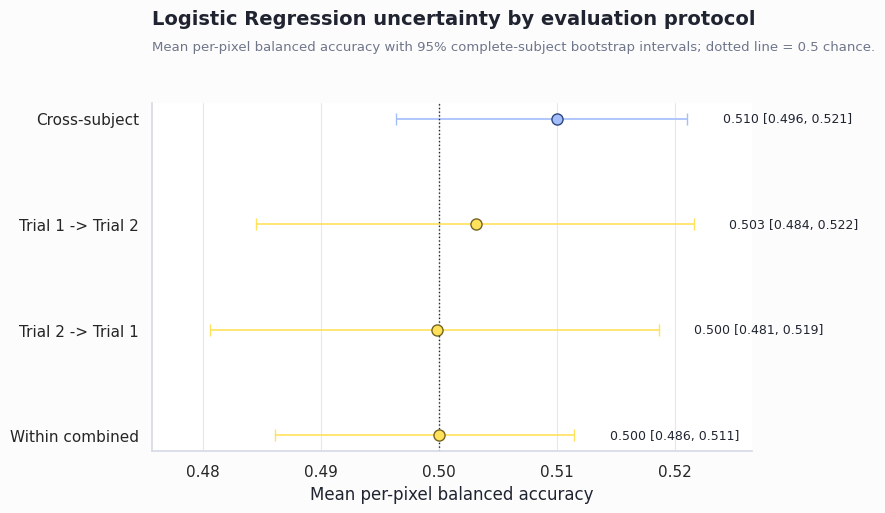

In [7]:
TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
}
GOLD = {"base": "#FFE15B", "dark": "#736422", "light": "#FFEA8F"}
BLUE = {"base": "#A3BEFA", "dark": "#2E4780", "light": "#CEDFFE"}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": TOKENS["surface"],
        "axes.facecolor": TOKENS["panel"],
        "axes.edgecolor": TOKENS["axis"],
        "axes.labelcolor": TOKENS["ink"],
        "grid.color": TOKENS["grid"],
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

interval_df = metrics_df[
    (metrics_df["method"] == "Logistic Regression")
    & metrics_df["ci_lower"].notna()
].copy()
direction_labels = {
    "cross-subject": "Cross-subject",
    "trial-1-to-trial-2": "Trial 1 -> Trial 2",
    "trial-2-to-trial-1": "Trial 2 -> Trial 1",
    "both directions": "Within combined",
}
interval_df["label"] = interval_df["direction"].map(direction_labels)
label_order = [
    "Cross-subject",
    "Trial 1 -> Trial 2",
    "Trial 2 -> Trial 1",
    "Within combined",
]
interval_df["label"] = pd.Categorical(
    interval_df["label"], categories=label_order, ordered=True
)
interval_df = interval_df.sort_values("label", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.2))
for _, row in interval_df.iterrows():
    family = BLUE if row["label"] == "Cross-subject" else GOLD
    ax.errorbar(
        row["mean_balanced_accuracy"],
        row["label"],
        xerr=np.array(
            [[row["mean_balanced_accuracy"] - row["ci_lower"]],
             [row["ci_upper"] - row["mean_balanced_accuracy"]]]
        ),
        fmt="o",
        color=family["base"],
        markeredgecolor=family["dark"],
        markeredgewidth=1.0,
        markersize=8,
        capsize=4,
        linewidth=1.2,
    )
    ax.text(
        row["ci_upper"] + 0.003,
        row["label"],
        f'{row["mean_balanced_accuracy"]:.3f} [{row["ci_lower"]:.3f}, {row["ci_upper"]:.3f}]',
        va="center",
        fontsize=9,
        color=TOKENS["ink"],
    )

ax.axvline(0.5, color=TOKENS["ink"], linestyle=":", linewidth=1.0)
ax.set_xlabel("Mean per-pixel balanced accuracy")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
sns.despine(ax=ax)
fig.subplots_adjust(top=0.78, left=0.22, right=0.82)
fig.text(
    ax.get_position().x0,
    0.96,
    "Logistic Regression uncertainty by evaluation protocol",
    ha="left",
    va="top",
    fontsize=14,
    fontweight="semibold",
    color=TOKENS["ink"],
)
fig.text(
    ax.get_position().x0,
    0.90,
    "Mean per-pixel balanced accuracy with 95% complete-subject bootstrap intervals; dotted line = 0.5 chance.",
    ha="left",
    va="top",
    fontsize=9.5,
    color=TOKENS["muted"],
)
plt.show()

## Takeaways

1. **Primary cross-subject estimate:** balanced accuracy is `0.5100` with 95% subject-bootstrap interval `[0.4964, 0.5211]`; the interval includes chance. The schema-v2 run reproduces the schema-v1 reference result exactly.
2. **Cross-trial directions:** Trial 1 -> Trial 2 reaches `0.5031` (`[0.4845, 0.5216]`) after selecting `correlation`; Trial 2 -> Trial 1 reaches `0.4998` (`[0.4806, 0.5187]`) after selecting `time+spectral`.
3. **Combined within-subject estimate:** balanced accuracy is `0.5000` with interval `[0.4861, 0.5115]`, mean sample IoU `0.3359`, and Hamming loss `0.4964`. It does not provide evidence above chance.
4. **Selection optimism remains visible:** mean best inner-CV balanced accuracy is `0.5792`, `0.5813`, and `0.6020` for cross-subject, Trial 1 -> Trial 2, and Trial 2 -> Trial 1, respectively, while held-out estimates remain near `0.5`.
5. **Scientific interpretation:** identity overlap alone did not improve reconstruction in this protocol. The cross-subject and within-subject estimates describe different populations and transfer targets, so their difference is not a pure model effect and must not be averaged into one score.

In [8]:
cross_model = metrics_df[
    (metrics_df["scope"] == "cross-subject")
    & (metrics_df["method"] == "Logistic Regression")
].iloc[0]
within_model = metrics_df[
    (metrics_df["scope"] == "within-subject combined")
    & (metrics_df["method"] == "Logistic Regression")
].iloc[0]

assert set(PROTOCOLS) == {"cross-subject", "within-subject"}
assert len(workflow_results["within-subject"].run_dirs) == 2
assert not audits_df["forbidden_leakage"].any()
assert len(grid_df) == 108
assert np.isfinite(metrics_df.select_dtypes(include=[np.number]).drop(columns=["ci_lower", "ci_upper"]).to_numpy()).all()
assert 0.0 <= cross_model["mean_balanced_accuracy"] <= 1.0
assert 0.0 <= within_model["mean_balanced_accuracy"] <= 1.0
print("LOGISTIC_REGRESSION_TRAINING_PROTOCOLS_VERIFIED")

LOGISTIC_REGRESSION_TRAINING_PROTOCOLS_VERIFIED
